In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vishweshvarrk/cohortdatasets/sample_submission.csv
/kaggle/input/datasets/vishweshvarrk/cohortdatasets/train.csv
/kaggle/input/datasets/vishweshvarrk/cohortdatasets/test.csv


In [36]:
#lock seed
random.seed(42)
np.random.seed(42)

#load datsets
traindf=pd.read_csv('/kaggle/input/datasets/vishweshvarrk/cohortdatasets/train.csv')
testdf = pd.read_csv('/kaggle/input/datasets/vishweshvarrk/cohortdatasets/test.csv')

#preview
traindf.head()

,id,uaudl,le,css,w,d,uil,r
0,1,100,10.5,L SHAPE,300,1045,1199,148
1,2,75,6.5,L SHAPE,450,481,568,192
2,3,50,6.5,rectangular,450,357,385,223
3,4,25,9.5,rectangular,300,572,304,149
4,5,50,5.5,L SHAPE,300,463,323,175


#section 1: Exploratory Data Analysis(EDA)

In [37]:
traindf.info()


print("any missing values:\n", traindf.isnull().sum())
traindf.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      117 non-null    int64  
 1   uaudl   117 non-null    int64  
 2   le      117 non-null    float64
 3   css     117 non-null    object 
 4   w       117 non-null    int64  
 5   d       117 non-null    int64  
 6   uil     117 non-null    int64  
 7   r       117 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 7.4+ KB
any missing values:
 id        0
uaudl     0
le        0
css       0
w         0
d         0
uil       0
r         0
dtype: int64


,id,uaudl,le,w,d,uil,r
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,59.000000,74.358974,8.363248,374.358974,644.726496,718.982906,189.495726
std,33.919021,40.399612,2.579448,75.319831,250.299497,411.935235,65.769664
min,1.000000,25.000000,4.500000,300.000000,300.000000,143.000000,67.000000
25%,30.000000,50.000000,6.500000,300.000000,433.000000,387.000000,141.000000
50%,59.000000,75.000000,8.500000,300.000000,628.000000,638.000000,175.000000
75%,88.000000,100.000000,10.500000,450.000000,867.000000,1011.000000,223.000000
max,117.000000,150.000000,12.500000,450.000000,1220.000000,1792.000000,404.000000


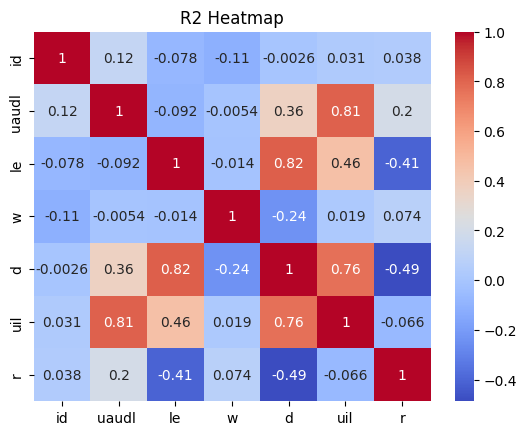

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

#make corelation matrix for better idea 
plt.figure()

sns.heatmap(traindf.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("R2 Heatmap")
plt.show()

In [39]:
#remove IDs column to prevent model from learning based on ID-noise
test_ids = testdf['id']
traindf=traindf.drop(columns=['id'])
testdf = testdf.drop(columns=['id'])


#convert css column to numerical for teh XGBoost model
traindf = pd.get_dummies(traindf,columns=['css'],drop_first=True)
testdf= pd.get_dummies(testdf,columns=['css'],drop_first=True)
#preview
traindf.head()

,uaudl,le,w,d,uil,r,css_rectangular
0,100,10.5,300,1045,1199,148,False
1,75,6.5,450,481,568,192,False
2,50,6.5,450,357,385,223,True
3,25,9.5,300,572,304,149,True
4,50,5.5,300,463,323,175,False


In [40]:
from sklearn.model_selection import train_test_split

#target variables ie teh dependent variables
targets=['d','r','uil']

#separate features and targets
x = traindf.drop(columns=targets) #x: features(independent variables)
y = traindf[targets]              #y: targets(dependent variables)


xtest = testdf#test doesnt hvae targets, hence testdf itself is out xtest

#spllit training data to get validation set to check performance
#80% training and 20%validation
xtrain,xval,ytrain,yval=train_test_split(x,y,test_size=0.2,random_state=42)

#get dimensions
print("Traoning shape:",xtrain.shape)
print("validation shape:",xval.shape)

Traoning shape: (93, 4)
validation shape: (24, 4)


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

#make the baseline using random forest and later boost using XGBoost
#using Random Forest since the data is limited
model = RandomForestRegressor(random_state=42)
#train on the training 93 rows
model.fit(xtrain,ytrain)

valpreds = model.predict(xval)

#calculate r2 score for each target
r2_d=r2_score(yval['d'],valpreds[:,0])
r2_r = r2_score(yval['r'],valpreds[:,1])
r2_uil = r2_score(yval['uil'],valpreds[:,2])

#mean r2 across all the targets
r2 = (r2_d+r2_r+r2_uil)/3
print("Results of baseline model\n")
print(f"R2 score for d: {r2_d:.5f}")
print(f"R2 score for r: {r2_r:.5f}")
print(f"R2 score for uil: {r2_uil:.5f}")

print(f"Mean R2 score of the baseline model: {r2:.5f}")

Results of baseline model

R2 score for d: 0.76577
R2 score for r: -0.27445
R2 score for uil: 0.98902
Mean R2 score of the baseline model: 0.49345


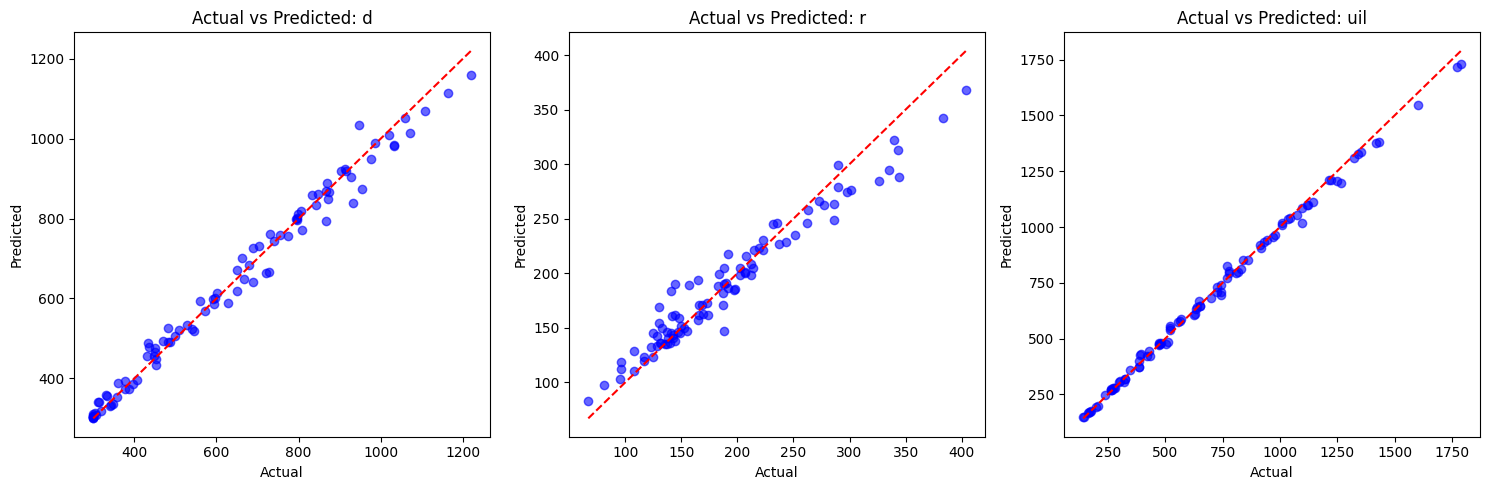

In [42]:
trainpreds = model.predict(xtrain)

fig,axes = plt.subplots(1,3,figsize=(15,5))

#plotting predicted vs actual for
#each target know if the current model is underfitting or overfitting
for i,target in enumerate(targets):
    #make scatter plot
    axes[i].scatter(ytrain[target],trainpreds[:,i],alpha =0.6,color='blue')

    maxval= max(max(trainpreds[:,i]),max(ytrain[target]))
    minval=min(min(trainpreds[:,i]),min(ytrain[target]))

    axes[i].plot([minval,maxval],[minval,maxval],'r--')

    axes[i].set_title(f'Actual vs Predicted: {target}')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    
plt.tight_layout()
plt.show()

shap plots for target:d


/tmp/ipykernel_55/2978673247.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shapvalues[:,:,0],xval)


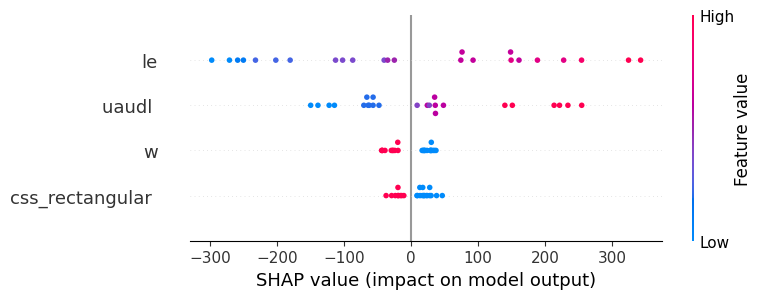

In [43]:
import shap
#initialize javascript for shap visualization
shap.initjs()
#to get info of how much each feature is contributing to the final prediction
#ie influence of each feature
explainer= shap.TreeExplainer(model)
shapvalues=explainer.shap_values(xval)

print("shap plots for target:d")
shap.summary_plot(shapvalues[:,:,0],xval)

In [46]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

#base physics
def getbase(df):
    df =df.copy()
    df.columns= df.columns.str.strip()
    df['moment'] =df['uaudl']*(df['le']**2)
    #new feature: load per lengt
    df['load_per_len'] =df['uaudl']/df['le'] 
    return df

xtrbase =getbase(xtrain)
xtebase=getbase(xtest)

#scaling dataser
sc1 = RobustScaler()
xtrsc =pd.DataFrame(sc1.fit_transform(xtrbase),columns=xtrbase.columns,index=xtrbase.index)
xtesc =pd.DataFrame(sc1.transform(xtebase),columns=xtebase.columns,index=xtebase.index)

#k fold stacking for d.
kf = KFold(n_splits=5,shuffle=True,random_state=42)
oofd = np.zeros(len(xtrsc))
dpreds = []

#predict for d
dmodels = [
    XGBRegressor(n_estimators=150,
                    learning_rate=0.05,
                 max_depth=3,
                 subsample=0.8,
                 random_state=42, 
                 verbosity=0),
    RandomForestRegressor(n_estimators=200,
                        max_depth=4,
                          random_state=42),
    Ridge(alpha=10.0)
]

for train_idx, val_idx in kf.split(xtrsc):
    xft,xfv =xtrsc.iloc[train_idx],xtrsc.iloc[val_idx]
    yft =ytrain['d'].iloc[train_idx]
    
    pval =np.zeros(len(val_idx))
    ptest =np.zeros(len(xtesc))
    
    for m in dmodels:
        m.fit(xft,yft)
        pval +=m.predict(xfv)/len(dmodels)
        ptest += m.predict(xtesc)/len(dmodels)
        
    oofd[val_idx] =pval
    dpreds.append(ptest)

#fina;l prediction
find = np.mean(dpreds,axis=0)

def addadv(df, pred_d):
    df = df.copy()
    df['pred_d'] =pred_d
    df['section_area'] = df['w']*df['pred_d']
    df['stiffness'] = (df['w']* (df['pred_d']**3))/12
    return df

xtradv = addadv(xtrbase,oofd)
xteadv =addadv(xtebase,find)

#scale rest of the features
sc2 = RobustScaler()
xtradvsc = pd.DataFrame(sc2.fit_transform(xtradv),columns=xtradv.columns,index=xtradv.index)
xteadvsc = pd.DataFrame(sc2.transform(xteadv), columns=xteadv.columns,index=xteadv.index)

# predict r and uil
xgb2 = MultiOutputRegressor(XGBRegressor(n_estimators=150,
                                            learning_rate=0.05,
                                             max_depth=3, 
                                             subsample=0.8,
                                             random_state=42,
                                             verbosity=0))
rf2 = MultiOutputRegressor(RandomForestRegressor(n_estimators=200, 
                                                     max_depth=5,
                                                     random_state=42))

xgb2.fit(xtradvsc,ytrain[['r','uil']])
rf2.fit(xtradvsc,ytrain[['r','uil']])

pxgb =xgb2.predict(xteadvsc)
prf =rf2.predict(xteadvsc)
finruil =(pxgb + prf)/2

#submission
submission =pd.DataFrame({
    'id':test_ids,
    'd':find,
    'uil':finruil[:,1],
    'r':finruil[:,0]
})

submission.to_csv('submission.csv',index=False)
submission.head()

,id,d,uil,r
0,1,485.886421,367.881120,168.429205
1,2,587.077764,363.007481,141.927384
2,3,700.609879,442.228692,119.176700
3,4,867.805257,1567.591615,204.969030
4,5,556.748243,426.662441,168.201984


In [45]:
# final_regr= MultiOutputRegressor(XGBRegressor(
#         n_estimators=4000,
#         learning_rate=0.008,#slow learnging
#         max_depth=3,
#         subsample=0.8,
#         colsample_bytree=0.9,
#         gamma=0.3,  #less overfitting
#         reg_lambda=2.5, #keep r stable
#         random_state=42,
#         verbosity=0

#     ))

# #fit on full training set and generate prediction
# final_regr.fit(xtrain_phy,ytrain)
# final_preds = final_regr.predict(xtest_phy)

# submission = pd.DataFrame({
#     'id':test_ids,
#     'd': final_preds[:,0],
#     'uil': final_preds[:,2],
#     'r': final_preds[:,1],
    
# })

# submission.to_csv('submission.csv',index=False)

# print("submission.csv generated")
# submission.head()
